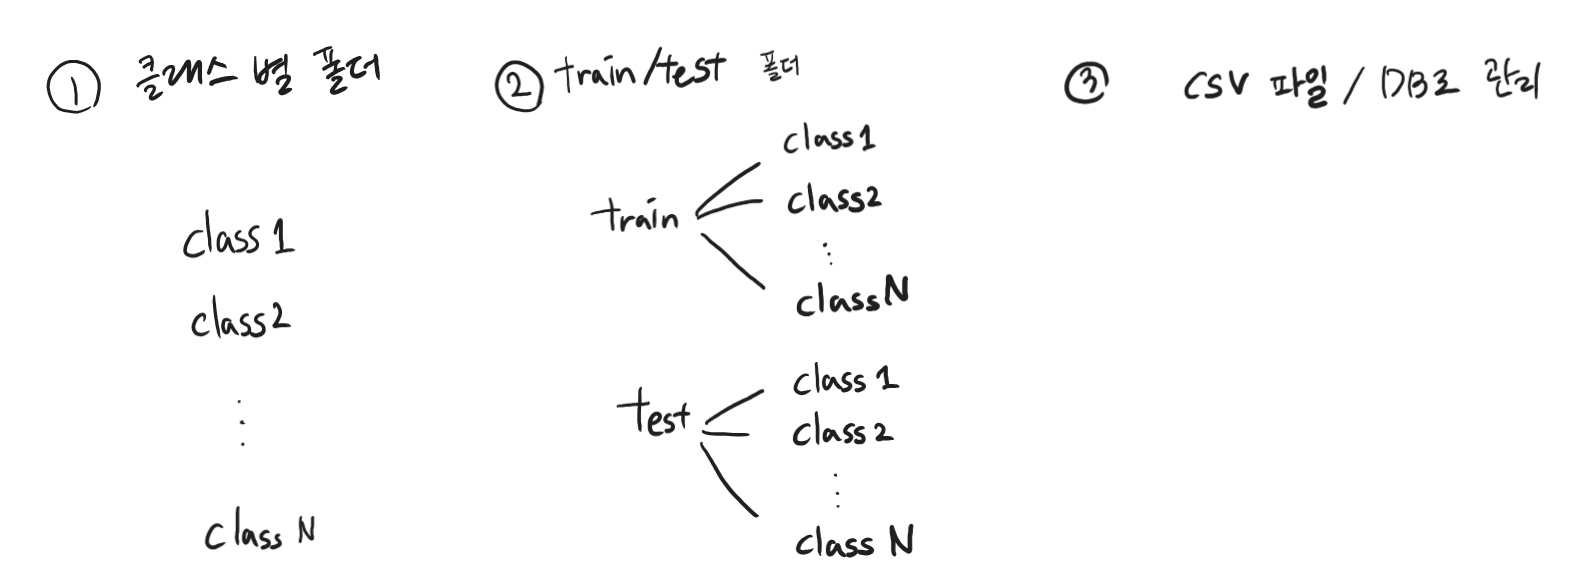

# 1번 방법(클래스 폴더)

## 필요 라이브러리 임포트

In [ ]:
import torch
from torchvision import transforms # 전처리
from torch.utils.data import Dataset, DataLoader # 데이터셋, 데이터로더
from PIL import Image # 이미지 처리
import glob # 파일 경로 다루기
import matplotlib.pyplot as plt # 시각화
import numpy as np

## glob 사용해보기

현재 이미지 폴더 상태  
/catdog  
&nbsp;&nbsp;/cat  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;cat1.jpg  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;cat2.jpg  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;...  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;cat10.jpg  
&nbsp;&nbsp;/dog  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;dog1.jpg  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;dog2.jpg  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;...  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;dog10.jpg

In [ ]:
glob.glob('./catdog/*')

['./catdog\\cat', './catdog\\dog']

In [ ]:
for folder in glob.glob('./catdog/*'):
  print(folder)
  print(glob.glob(f'{folder}/*.*'))

./catdog\cat
['./catdog\\cat\\cat1.jpg', './catdog\\cat\\cat10.jpg', './catdog\\cat\\cat2.jpg', './catdog\\cat\\cat3.jpg', './catdog\\cat\\cat4.jpg', './catdog\\cat\\cat5.jpg', './catdog\\cat\\cat6.jpg', './catdog\\cat\\cat7.jpg', './catdog\\cat\\cat8.jpg', './catdog\\cat\\cat9.jpg']
./catdog\dog
['./catdog\\dog\\dog1.jpg', './catdog\\dog\\dog10.jpg', './catdog\\dog\\dog2.jpg', './catdog\\dog\\dog3.jpg', './catdog\\dog\\dog4.jpg', './catdog\\dog\\dog5.jpg', './catdog\\dog\\dog6.jpg', './catdog\\dog\\dog7.jpg', './catdog\\dog\\dog8.jpg', './catdog\\dog\\dog9.jpg']


In [ ]:
path = './catdog'
glob.glob(path+'/dog/*.*')

['./catdog/dog\\dog1.jpg',
 './catdog/dog\\dog10.jpg',
 './catdog/dog\\dog2.jpg',
 './catdog/dog\\dog3.jpg',
 './catdog/dog\\dog4.jpg',
 './catdog/dog\\dog5.jpg',
 './catdog/dog\\dog6.jpg',
 './catdog/dog\\dog7.jpg',
 './catdog/dog\\dog8.jpg',
 './catdog/dog\\dog9.jpg']

In [ ]:
path = './catdog'
glob.glob(path+'/cat/*.*')

['./catdog/cat\\cat1.jpg',
 './catdog/cat\\cat10.jpg',
 './catdog/cat\\cat2.jpg',
 './catdog/cat\\cat3.jpg',
 './catdog/cat\\cat4.jpg',
 './catdog/cat\\cat5.jpg',
 './catdog/cat\\cat6.jpg',
 './catdog/cat\\cat7.jpg',
 './catdog/cat\\cat8.jpg',
 './catdog/cat\\cat9.jpg']

## custom dataset 만들기

1. torch.utils.data의 Dataset 상속받는 클래스 생성
2. init, len, getitem 메소드를 만든다
- init: 경로 설정, train과 test 분리, 정답 데이터 리스트 만들기
- len: 전체 데이터셋 개수 리턴
- getitem: 특정 번호의 이미지와 정답 리턴


In [ ]:
class CatDog(Dataset):
  def __init__(self, path, train=True, transform=None): # path: 이미지가 있는 경로 train: train인지 test인지 transform: 사용할 transform
    self.path = path # ./catdog
    self.transform = transform

    # glob으로 이미지 경로 불러오기
    self.cat_list = glob.glob(path+'/cat/*.*')
    self.dog_list = glob.glob(path+'/dog/*.*')

    # train, test 분리 + 정답 데이터 리스트 만들기
    # train 70 test 30
    # 이미지 70퍼센트 가져오기
    cat_idx = int(len(self.cat_list) * 0.7)
    dog_idx = int(len(self.dog_list) * 0.7)
    if train == True:
      self.data_list = self.cat_list[:cat_idx] + self.dog_list[:dog_idx]
      # 정답 리스트 만들기(cat 0, dog 1)
      self.label_list = [0] * cat_idx + [1] * dog_idx
    else:
      self.data_list = self.cat_list[cat_idx:] + self.dog_list[dog_idx:]
      self.label_list = [0] * len(self.cat_list[cat_idx:]) + [1] * len(self.cat_list[dog_idx:]) # 0은 cat, 1은 dog

  def __len__(self):
    return len(self.data_list)

  def __getitem__(self, idx):
    img_path = self.data_list[idx] # data_list에는 경로가 적혀 있음
    label = self.label_list[idx] # 정답
    img = Image.open(img_path) # 경로를 통해 이미지 불러오기

    if self.transform is not None: # transform 있으면
      img = self.transform(img) # 전처리한 이미지

    return img, label

## 전처리

In [ ]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224))
])

In [ ]:
path = './catdog'
train_data = CatDog(path=path, train=True, transform=data_transform)
test_data = CatDog(path=path, train=False, transform=data_transform)

In [ ]:
train_data.data_list

['./catdog/cat\\cat1.jpg',
 './catdog/cat\\cat10.jpg',
 './catdog/cat\\cat2.jpg',
 './catdog/cat\\cat3.jpg',
 './catdog/cat\\cat4.jpg',
 './catdog/cat\\cat5.jpg',
 './catdog/cat\\cat6.jpg',
 './catdog/dog\\dog1.jpg',
 './catdog/dog\\dog10.jpg',
 './catdog/dog\\dog2.jpg',
 './catdog/dog\\dog3.jpg',
 './catdog/dog\\dog4.jpg',
 './catdog/dog\\dog5.jpg',
 './catdog/dog\\dog6.jpg']

In [ ]:
train_data.label_list

[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]

In [ ]:
img, label = train_data[0]

In [ ]:
# 전처리 되어서 tensor로 반환
img

tensor([[[0.2784, 0.2804, 0.2893,  ..., 0.4522, 0.4471, 0.4471],
         [0.2733, 0.2854, 0.3009,  ..., 0.4713, 0.4740, 0.4740],
         [0.2652, 0.2869, 0.3101,  ..., 0.4851, 0.4917, 0.4917],
         ...,
         [0.2275, 0.2275, 0.2271,  ..., 0.3562, 0.3457, 0.3219],
         [0.2275, 0.2275, 0.2271,  ..., 0.3417, 0.3397, 0.3394],
         [0.2275, 0.2275, 0.2271,  ..., 0.3696, 0.3375, 0.3122]],

        [[0.1647, 0.1667, 0.1744,  ..., 0.3345, 0.3294, 0.3294],
         [0.1596, 0.1716, 0.1860,  ..., 0.3536, 0.3564, 0.3564],
         [0.1500, 0.1717, 0.1938,  ..., 0.3674, 0.3740, 0.3740],
         ...,
         [0.1294, 0.1294, 0.1298,  ..., 0.3162, 0.3084, 0.2867],
         [0.1294, 0.1294, 0.1298,  ..., 0.3017, 0.3024, 0.3041],
         [0.1294, 0.1294, 0.1298,  ..., 0.3296, 0.3002, 0.2769]],

        [[0.1098, 0.1118, 0.1199,  ..., 0.2953, 0.2902, 0.2902],
         [0.1047, 0.1167, 0.1315,  ..., 0.3144, 0.3172, 0.3172],
         [0.0996, 0.1212, 0.1436,  ..., 0.3282, 0.3348, 0.

In [ ]:
label

0

In [ ]:
img.shape

torch.Size([3, 224, 224])

In [28]:
# 이미지 확인 함수
category = ['cat', 'dog']
def imgshow(data, label, transform=True):
  if transform:
    numpy_array = data.numpy() # tensor -> numpy
    img = numpy_array.transpose(1,2,0) # channel,w,h -> w,h,channel
  else:
    img = np.array(data) # PIL -> numpy
  plt.title(category[label])
  plt.axis('off')
  plt.imshow(img)
  plt.show()

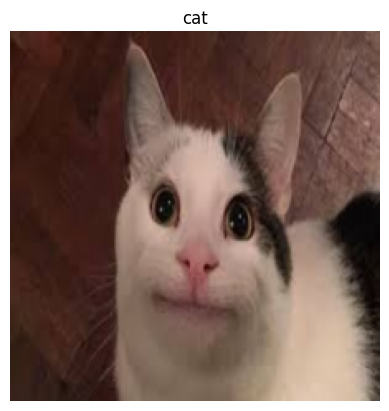

In [ ]:
imgshow(img, label)

## Dataloader

In [ ]:
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4)

In [ ]:
train_loader.batch_size

4

In [ ]:
img, label = next(iter(train_loader))

In [ ]:
type(img)

torch.Tensor

In [ ]:
img.shape

torch.Size([4, 3, 224, 224])

In [ ]:
label.shape

torch.Size([4])

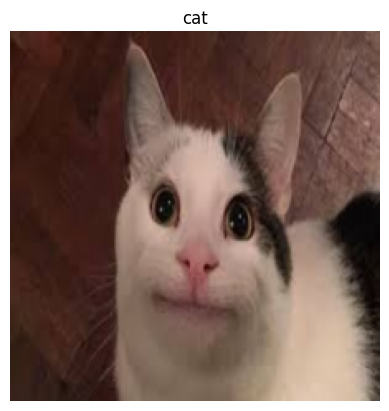

In [ ]:
imgshow(img[0], label[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


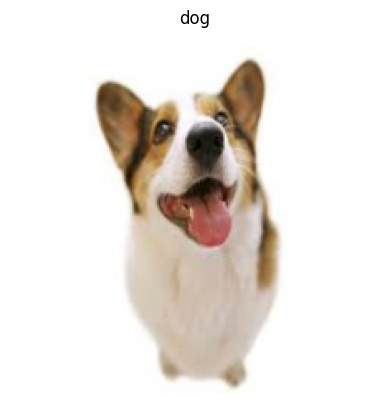

In [ ]:
imgshow(img[1], label[1])

# 2번 방법(train, test 폴더 안에 클래스 폴더)

## train, test에 각 클래스 폴더 만들기

현재 이미지 폴더 상태
/catdog  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/cat  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/dog    

-> train/test로 나눈 후  
/animal  
&nbsp;&nbsp;&nbsp;&nbsp;/train  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/cat  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/dog  
&nbsp;&nbsp;&nbsp;&nbsp;/test  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/cat  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;/dog

In [ ]:
import os
import shutil

In [ ]:
# 이미지 복사(shutil.copy) / 이미지 이동(shutil.move)
def dataset_split(folder, train_cnt=40):
  directory_list = ['./animal/train', './animal/test']
  img_path_list = os.listdir(f'./catdog/{folder}') # 이미지 경로 리스트

  for directory in directory_list:
    if not os.path.isdir(directory+'/'+folder): # 클래스 폴더 없으면 만들기
      os.makedirs(directory+'/'+folder) # 상위 디렉토리 없으면 상위 디렉토리도 만든다
  for cnt in range(len(img_path_list)):
    filename = img_path_list[cnt]
    if cnt < train_cnt: # train 폴더에 복사
      print(f'{filename} train 폴더에 복사')
      shutil.copy(f'./catdog/{folder}/{filename}', f'./animal/train/{folder}/{filename}')
    else: # test 폴더에 복사
      print(f'{filename} test 폴더에 복사')
      shutil.copy(f'./catdog/{folder}/{filename}', f'./animal/test/{folder}/{filename}')

In [ ]:
dataset_split('dog', 7)

dog1.jpg train 폴더에 복사
dog10.jpg train 폴더에 복사
dog2.jpg train 폴더에 복사
dog3.jpg train 폴더에 복사
dog4.jpg train 폴더에 복사
dog5.jpg train 폴더에 복사
dog6.jpg train 폴더에 복사
dog7.jpg test 폴더에 복사
dog8.jpg test 폴더에 복사
dog9.jpg test 폴더에 복사


In [ ]:
dataset_split('cat', 7)

cat1.jpg train 폴더에 복사
cat10.jpg train 폴더에 복사
cat2.jpg train 폴더에 복사
cat3.jpg train 폴더에 복사
cat4.jpg train 폴더에 복사
cat5.jpg train 폴더에 복사
cat6.jpg train 폴더에 복사
cat7.jpg test 폴더에 복사
cat8.jpg test 폴더에 복사
cat9.jpg test 폴더에 복사


In [ ]:
len(os.listdir('./animal/train/dog')), len(os.listdir('./animal/test/dog'))

(7, 3)

In [ ]:
len(os.listdir('./animal/train/cat')), len(os.listdir('./animal/test/cat'))

(7, 3)

## 필요 라이브러리 임포트

In [ ]:
import torch
from torchvision import transforms # 전처리
from torchvision.datasets import ImageFolder # 이미지 폴더로부터 데이터셋
from torch.utils.data import DataLoader # 데이터셋, 데이터로더
from PIL import Image # 이미지 처리
import matplotlib.pyplot as plt # 시각화
import numpy as np

## 전처리

In [ ]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224))
])

## custom dataset 만들기
torchvision의 datasets의 ImageFolder를 이용한다.  
바로 transform을 적용할 수 있다.

In [ ]:
train_data = ImageFolder('./animal/train', transform=data_transform)
test_data = ImageFolder('./animal/test', transform=data_transform)

In [ ]:
train_data

Dataset ImageFolder
    Number of datapoints: 14
    Root location: ./animal/train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
           )

In [ ]:
test_data

Dataset ImageFolder
    Number of datapoints: 6
    Root location: ./animal/test
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
           )

In [ ]:
# 이미지 경로와 정답 라벨
train_data.imgs

[('./animal/train\\cat\\cat1.jpg', 0),
 ('./animal/train\\cat\\cat10.jpg', 0),
 ('./animal/train\\cat\\cat2.jpg', 0),
 ('./animal/train\\cat\\cat3.jpg', 0),
 ('./animal/train\\cat\\cat4.jpg', 0),
 ('./animal/train\\cat\\cat5.jpg', 0),
 ('./animal/train\\cat\\cat6.jpg', 0),
 ('./animal/train\\dog\\dog1.jpg', 1),
 ('./animal/train\\dog\\dog10.jpg', 1),
 ('./animal/train\\dog\\dog2.jpg', 1),
 ('./animal/train\\dog\\dog3.jpg', 1),
 ('./animal/train\\dog\\dog4.jpg', 1),
 ('./animal/train\\dog\\dog5.jpg', 1),
 ('./animal/train\\dog\\dog6.jpg', 1)]

In [ ]:
# 클래스 확인
train_data.classes

['cat', 'dog']

In [ ]:
train_data.class_to_idx

{'cat': 0, 'dog': 1}

In [ ]:
# 이미지 확인 함수
category = ['cat', 'dog']
def imgshow(data, label, transform=True):
  if transform:
    numpy_array = data.numpy() # tensor -> numpy
    img = numpy_array.transpose(1,2,0) # channel,w,h -> w,h,channel
  else:
    img = np.array(data) # PIL -> numpy
  plt.title(category[label])
  plt.axis('off')
  plt.imshow(img)
  plt.show()

In [ ]:
img, label = train_data[0]

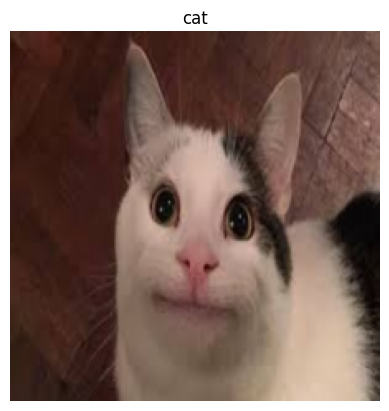

In [ ]:
imgshow(img, label)

In [ ]:
img.shape

torch.Size([3, 224, 224])

+전처리 없이 했을 때

In [ ]:
train_data_no_transform = ImageFolder('./animal/train')

In [ ]:
i, l = train_data_no_transform[0]

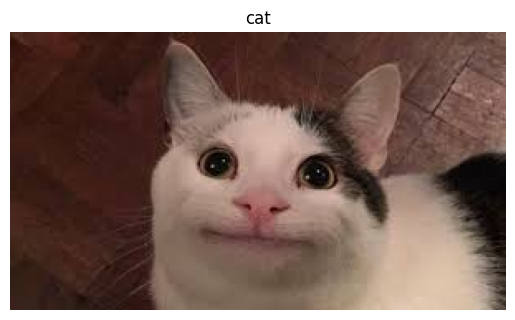

In [ ]:
imgshow(i, l, False)

In [ ]:
np.array(i).shape

(168, 300, 3)

## DataLoader

In [ ]:
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4)

In [ ]:
train_loader.batch_size

4

In [ ]:
img, label = next(iter(train_loader))

In [ ]:
type(img)

torch.Tensor

In [ ]:
img.shape

torch.Size([4, 3, 224, 224])

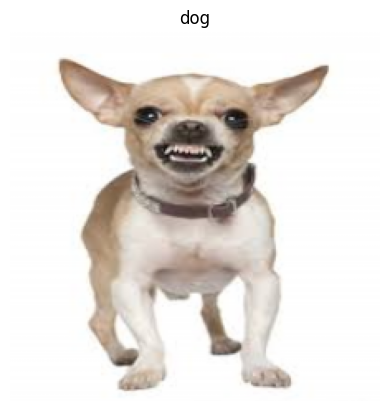

In [ ]:
imgshow(img[0], label[0])

# 3번 방법(통합 파일 기반 관리)

## csv 파일 만들기
train.csv, test.csv

그 안에 file_path와 label 컬럼 생성

train.csv
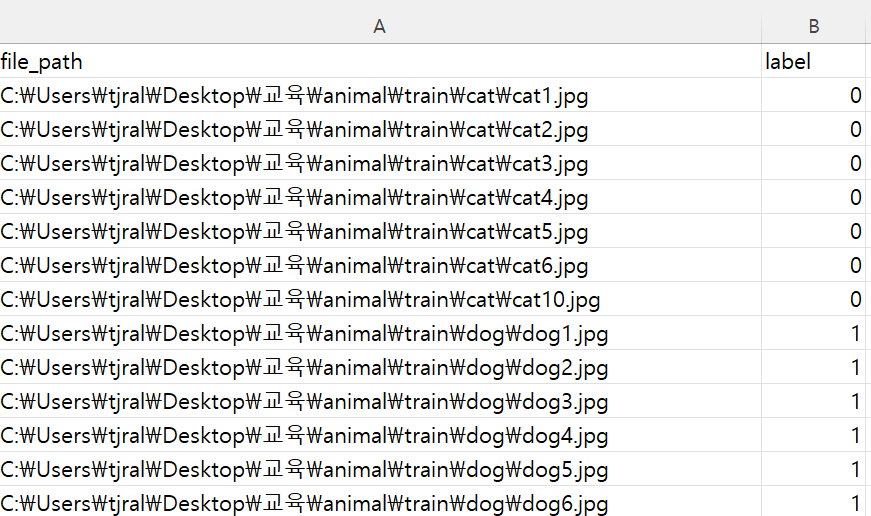

test.csv  
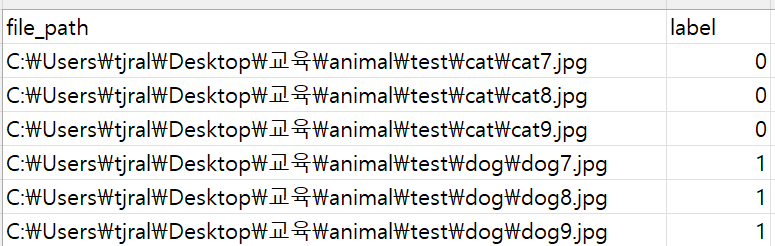

## csv 파일 읽어서 이미지 출력

In [2]:
import pandas as pd
from PIL import Image

In [9]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.head()

,file_path,label
0,C:\Users\tjral\Desktop\교육\animal\train\cat\cat...,0
1,C:\Users\tjral\Desktop\교육\animal\train\cat\cat...,0
2,C:\Users\tjral\Desktop\교육\animal\train\cat\cat...,0
3,C:\Users\tjral\Desktop\교육\animal\train\cat\cat...,0
4,C:\Users\tjral\Desktop\교육\animal\train\cat\cat...,0


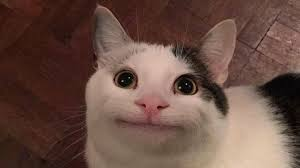

In [10]:
Image.open(train_df.loc[0, 'file_path'])

In [17]:
# 넘파이 배열
train_df['file_path'].values

array(['C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat1.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat2.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat3.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat4.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat5.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat6.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat10.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog1.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog2.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog3.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog4.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog5.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog6.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog10.jpg'],
      dtype=objec

## 필요 라이브러리 임포트

In [5]:
import torch
from torchvision import transforms # 전처리
from torch.utils.data import Dataset, DataLoader # 데이터셋, 데이터로더
import matplotlib.pyplot as plt # 시각화
import numpy as np

## 전처리

In [19]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224))
])

## custom dataset 만들기

In [18]:
class CatDog(Dataset):
  def __init__(self, df, transform=None): # df: file_path와 label이 담긴 데이터프레임, transform: 사용할 transform
    self.data_list = df['file_path'].values # 넘파이 배열로
    self.label_list = df['label'].values # 넘파이 배열로
    self.transform = transform

  def __len__(self):
    return len(self.data_list)

  def __getitem__(self, idx):
    img_path = self.data_list[idx] # data_list에는 경로가 적혀 있음
    label = self.label_list[idx] # 정답
    img = Image.open(img_path) # 경로를 통해 이미지 불러오기

    if self.transform is not None: # transform 있으면
      img = self.transform(img) # 전처리한 이미지

    return img, label

In [20]:
train_data = CatDog(train_df, data_transform)
test_data = CatDog(train_df, data_transform)

In [22]:
train_data.data_list

array(['C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat1.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat2.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat3.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat4.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat5.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat6.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\cat\\cat10.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog1.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog2.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog3.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog4.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog5.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog6.jpg',
       'C:\\Users\\tjral\\Desktop\\교육\\animal\\train\\dog\\dog10.jpg'],
      dtype=objec

In [23]:
len(train_data)

14

In [24]:
img, label = train_data[0]

In [25]:
img.shape

torch.Size([3, 224, 224])

In [27]:
label.item()

0

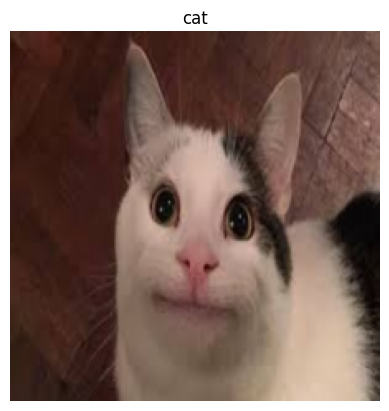

In [29]:
imgshow(img, label, transform=True)

## DataLoader

In [30]:
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4)

In [31]:
train_loader.batch_size

4

In [35]:
imgs, labels = next(iter(train_loader))

In [36]:
imgs.shape

torch.Size([4, 3, 224, 224])

In [37]:
labels

tensor([0, 1, 1, 0])

In [38]:
img = imgs[0]
label = labels[0]

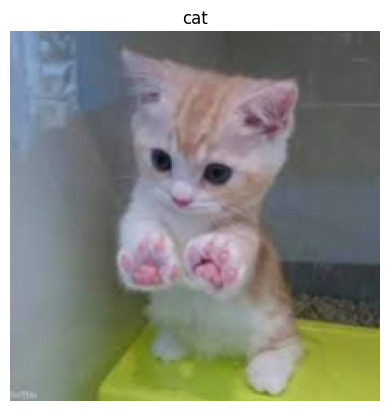

In [39]:
imgshow(img, label, transform=True)